In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load the CSV file
df = pd.read_csv("workouts.csv")

In [ ]:
# Load the CSV file
#df = pd.read_csv("/Users/ed9868/Downloads/workouts.csv")

In [76]:

# Show first 5 rows
print("=== First 5 Rows ===")
print(df.head())

# Show column names
print("\n=== Column Names ===")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")


=== First 5 Rows ===
           Title WorkoutType WorkoutDescription  PlannedDuration  \
0  Z2 - לפי דופק         Run                NaN         1.333333   
1    שחייה - ערב        Swim                NaN         1.000000   
2         Cardio       Other                NaN              NaN   
3    שחייה - ערב        Swim                NaN         1.000000   
4        מתפתח 2         Run                NaN         1.500000   

   PlannedDistanceInMeters  WorkoutDay  CoachComments  DistanceInMeters  \
0                      NaN  2026-02-01            NaN      12528.839844   
1                      NaN  2026-02-01            NaN       2000.000000   
2                      NaN  2026-02-01            NaN          0.000000   
3                      NaN  2026-02-02            NaN       2200.000000   
4                      NaN  2026-02-03            NaN      14084.070312   

   PowerAverage  PowerMax  ...  PWRZone3Minutes  PWRZone4Minutes  \
0         230.0     419.0  ...             14.0    

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    128 non-null    object 
 1   WorkoutType              129 non-null    object 
 2   WorkoutDescription       31 non-null     object 
 3   PlannedDuration          94 non-null     float64
 4   PlannedDistanceInMeters  5 non-null      float64
 5   WorkoutDay               129 non-null    object 
 6   CoachComments            0 non-null      float64
 7   DistanceInMeters         112 non-null    float64
 8   PowerAverage             58 non-null     float64
 9   PowerMax                 58 non-null     float64
 10  Energy                   58 non-null     float64
 11  AthleteComments          0 non-null      float64
 12  TimeTotalInHours         113 non-null    float64
 13  VelocityAverage          112 non-null    float64
 14  VelocityMax              0

In [78]:
df

,Title,WorkoutType,WorkoutDescription,PlannedDuration,PlannedDistanceInMeters,WorkoutDay,CoachComments,DistanceInMeters,PowerAverage,PowerMax,...,PWRZone3Minutes,PWRZone4Minutes,PWRZone5Minutes,PWRZone6Minutes,PWRZone7Minutes,PWRZone8Minutes,PWRZone9Minutes,PWRZone10Minutes,Rpe,Feeling
0,Z2 - לפי דופק,Run,NaN,1.333333,NaN,2026-02-01,NaN,12528.839844,230.0,419.0,...,14.0,44.0,3.0,18.0,NaN,NaN,NaN,NaN,1.0,1.0
1,שחייה - ערב,Swim,NaN,1.000000,NaN,2026-02-01,NaN,2000.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,7.0
2,Cardio,Other,NaN,NaN,NaN,2026-02-01,NaN,0.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,שחייה - ערב,Swim,NaN,1.000000,NaN,2026-02-02,NaN,2200.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
4,מתפתח 2,Run,NaN,1.500000,NaN,2026-02-03,NaN,14084.070312,244.0,446.0,...,1.0,1.0,2.0,84.0,NaN,NaN,NaN,NaN,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,שינויי קצב בסיס Z1-Z2-Z5 X10,Run,NaN,1.366667,NaN,2026-04-13,NaN,10823.000000,234.0,3108.0,...,2.0,8.0,21.0,51.0,NaN,NaN,NaN,NaN,2.0,1.0
125,שחייה בוקר אפק,Swim,NaN,1.000000,NaN,2026-04-14,NaN,2600.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0
126,Black,Bike,TrainerRoad - Black Achievable • Endurance 4.3...,1.000000,NaN,2026-04-14,NaN,15055.830078,114.0,182.0,...,7.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
127,Carillon,Bike,TrainerRoad - Carillon Productive • Sweet Spot...,1.000000,NaN,2026-04-15,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
selected_columns = [
    'Title', 'WorkoutType', 'WorkoutDay', 'PlannedDuration', 'Rpe', 'Feeling', 'TSS', 'IF',
    'HeartRateAverage', 'DistanceInMeters', 'PlannedDistanceInMeters',
    'PowerAverage', 'TimeTotalInHours', 'CadenceAverage'
]
df_selected = df[selected_columns].copy()

# Convert WorkoutDay to datetime
df_selected['WorkoutDay'] = pd.to_datetime(df_selected['WorkoutDay'], errors='coerce')

# Add DayOfWeek right after WorkoutDay
df_selected.insert(
    df_selected.columns.get_loc('WorkoutDay') + 1,
    'DayOfWeek',
    df_selected['WorkoutDay'].dt.day_name()
)

# Add WeekOfMonth right after DayOfWeek (e.g. "Week_1", "Week_2", ...)
df_selected.insert(
    df_selected.columns.get_loc('DayOfWeek') + 1,
    'WeekOfMonth',
    df_selected['WorkoutDay'].apply(
        lambda d: f"Week_{(d.day - 1) // 7 + 1}" if pd.notnull(d) else None
    )
)

df_selected.head(23)

,Title,WorkoutType,WorkoutDay,DayOfWeek,WeekOfMonth,PlannedDuration,Rpe,Feeling,TSS,IF,HeartRateAverage,DistanceInMeters,PlannedDistanceInMeters,PowerAverage,TimeTotalInHours,CadenceAverage
0,Z2 - לפי דופק,Run,2026-02-01,Sunday,Week_1,1.333333,1.0,1.0,63.03,0.638983,136.0,12528.839844,NaN,230.0,1.382449,162.0
1,שחייה - ערב,Swim,2026-02-01,Sunday,Week_1,1.000000,2.0,7.0,54.96,0.907997,124.0,2000.000000,NaN,NaN,0.734217,24.0
2,Cardio,Other,2026-02-01,Sunday,Week_1,NaN,NaN,NaN,34.39,0.582699,103.0,0.000000,NaN,NaN,0.916243,NaN
3,שחייה - ערב,Swim,2026-02-02,Monday,Week_1,1.000000,2.0,1.0,59.49,0.900688,126.0,2200.000000,NaN,NaN,0.814192,24.0
4,מתפתח 2,Run,2026-02-03,Tuesday,Week_1,1.500000,3.0,1.0,78.94,0.685620,144.0,14084.070312,NaN,244.0,1.500444,165.0
5,Treadmill Running,Run,2026-02-03,Tuesday,Week_1,NaN,1.0,5.0,11.78,0.734022,139.0,1780.000000,NaN,199.0,0.205412,133.0
6,רכיבה בסמי עופר מ6-7:30,Bike,2026-02-05,Thursday,Week_1,1.500000,2.0,1.0,59.08,0.676354,140.0,25056.449219,NaN,NaN,1.161265,NaN
7,Cardio,Other,2026-02-05,Thursday,Week_1,NaN,NaN,NaN,37.17,0.613531,110.0,0.000000,NaN,NaN,0.894152,NaN
8,ריצת נפח + 4טמפו,Run,2026-02-06,Friday,Week_1,1.908056,2.0,1.0,111.61,0.712200,148.0,19012.400391,19000.0,248.0,1.953382,169.0
9,רכיבת נפח,Bike,2026-02-07,Saturday,Week_1,3.250000,3.0,1.0,224.25,0.766604,155.0,84404.617188,NaN,NaN,3.342481,NaN


## Tss Summary 

In [80]:
# Weekly summary (Monday to Sunday)
df_work = df_selected.dropna(subset=['WorkoutDay']).copy()

def fmt_hhmm(h):
    if pd.isna(h) or h == 0:
        return '0:00'
    sign = '-' if h < 0 else ''
    ah = abs(h)
    return f"{sign}{int(ah)}:{int(round((ah % 1) * 60)):02d}"

# Group Mon-Sun
df_work['WeekStart'] = df_work['WorkoutDay'].dt.to_period('W-SUN').apply(lambda p: p.start_time)
df_work['WeekLabel'] = df_work['WeekStart'].dt.strftime('%b %d') + ' - ' + (df_work['WeekStart'] + pd.Timedelta(days=6)).dt.strftime('%b %d')

# Convert numeric columns
df_work['DistanceKm'] = pd.to_numeric(df_work['DistanceInMeters'], errors='coerce') / 1000
df_work['Hours'] = pd.to_numeric(df_work['TimeTotalInHours'], errors='coerce')
df_work['PlannedDistKm'] = pd.to_numeric(df_work['PlannedDistanceInMeters'], errors='coerce') / 1000
df_work['PlannedDur'] = pd.to_numeric(df_work['PlannedDuration'], errors='coerce')

# --- Swim ---
swim_weekly = df_work[df_work['WorkoutType'] == 'Swim'].groupby('WeekLabel')['DistanceKm'].sum()

# --- Run ---
run_data = df_work[df_work['WorkoutType'] == 'Run'].groupby('WeekLabel')
run_dist = run_data['DistanceKm'].sum()
run_planned_dist = run_data['PlannedDistKm'].sum()
run_planned_dur = run_data['PlannedDur'].sum()

# --- Bike ---
bike_data = df_work[df_work['WorkoutType'] == 'Bike'].groupby('WeekLabel')
bike_hours = bike_data['Hours'].sum()
bike_planned_dur = bike_data['PlannedDur'].sum()

# Total TSS per week
tss_weekly = df_work.groupby('WeekLabel')['TSS'].apply(lambda x: pd.to_numeric(x, errors='coerce').sum())

# Build summary table
weekly_summary = pd.DataFrame({
    'Swim (km)': swim_weekly,
    'Run (km)': run_dist,
    'Run Planned Dist (km)': run_planned_dist,
    'Run Planned Dur': run_planned_dur,
    'Bike': bike_hours,
    'Bike Planned Dur': bike_planned_dur,
    'Total TSS': tss_weekly
}).fillna(0)
weekly_summary['Total TSS'] = weekly_summary['Total TSS'].round(0).astype(int)
weekly_summary = weekly_summary.round(2)

# Sort by actual date
week_order = df_work.drop_duplicates('WeekLabel').sort_values('WeekStart').set_index('WeekLabel').index
weekly_summary = weekly_summary.reindex(week_order)

for col in ['Run Planned Dur', 'Bike', 'Bike Planned Dur']:
    weekly_summary[col] = weekly_summary[col].apply(fmt_hhmm)

weekly_summary

,Swim (km),Run (km),Run Planned Dist (km),Run Planned Dur,Bike,Bike Planned Dur,Total TSS
WeekLabel,,,,,,,
Jan 26 - Feb 01,2.00,12.53,0.00,1:20,0:00,0:00,152
Feb 02 - Feb 08,2.20,47.51,19.00,4:44,4:30,4:45,652
Feb 09 - Feb 15,7.15,37.59,0.00,3:52,3:11,6:45,649
Feb 16 - Feb 22,4.18,32.84,0.00,3:25,5:47,6:05,681
Feb 23 - Mar 01,2.33,31.69,21.10,3:44,3:51,5:45,437
Mar 02 - Mar 08,0.00,43.15,0.00,4:10,6:28,5:00,647
Mar 09 - Mar 15,4.72,49.62,0.00,5:41,10:15,10:46,858
Mar 16 - Mar 22,4.58,38.02,0.00,4:11,5:45,5:45,710
Mar 23 - Mar 29,7.55,27.07,0.00,4:15,5:16,5:16,636


In [81]:
# Weekly TSS totals (Monday to Sunday)
df_tss = df_selected.dropna(subset=['WorkoutDay']).copy()
df_tss['TSS'] = pd.to_numeric(df_tss['TSS'], errors='coerce')
df_tss['TimeTotalInHours'] = pd.to_numeric(df_tss['TimeTotalInHours'], errors='coerce')
df_tss['WeekStart'] = df_tss['WorkoutDay'].dt.to_period('W-SUN').apply(lambda p: p.start_time)
df_tss['WeekLabel'] = df_tss['WeekStart'].dt.strftime('%b %d') + ' - ' + (df_tss['WeekStart'] + pd.Timedelta(days=6)).dt.strftime('%b %d')

# Filter only Swim/Run/Bike for hours
df_srb = df_tss[df_tss['WorkoutType'].isin(['Swim', 'Run', 'Bike'])]
hours_by_week = df_srb.groupby(['WeekStart', 'WeekLabel'])['TimeTotalInHours'].sum().reset_index()
hours_by_week = hours_by_week.sort_values('WeekStart').set_index('WeekLabel').drop(columns='WeekStart')

tss_by_week = df_tss.groupby(['WeekStart', 'WeekLabel'])['TSS'].sum().reset_index()
tss_by_week = tss_by_week.sort_values('WeekStart').set_index('WeekLabel').drop(columns='WeekStart')
tss_by_week['TSS'] = tss_by_week['TSS'].round(0).astype(int)
tss_by_week['Total Hours (S/R/B)'] = hours_by_week['TimeTotalInHours'].apply(fmt_hhmm)
tss_by_week

,TSS,Total Hours (S/R/B)
WeekLabel,,
Jan 26 - Feb 01,152,2:07
Feb 02 - Feb 08,652,10:19
Feb 09 - Feb 15,649,9:48
Feb 16 - Feb 22,681,10:44
Feb 23 - Mar 01,437,7:42
Mar 02 - Mar 08,647,11:21
Mar 09 - Mar 15,858,17:27
Mar 16 - Mar 22,710,11:39
Mar 23 - Mar 29,636,10:55


## Annual Training Plan — Race 20/09/2026

In [ ]:
# Training Plan — Race: 20/09/2026
race_date = pd.Timestamp('2026-09-20')

# Phase schedule from coach (Kony) — starts May 31
coach_plan = [
    ('2026-05-31', '2026-06-06', 'Base 1 - Week 1', 10.25),
    ('2026-06-07', '2026-06-13', 'Base 1 - Week 2', 12.25),
    ('2026-06-14', '2026-06-20', 'Base 1 - Week 4', 7.25),
    ('2026-06-21', '2026-06-27', 'Base 2 - Week 1', 10.75),
    ('2026-06-28', '2026-07-04', 'Base 2 - Week 2', 13.0),
    ('2026-07-05', '2026-07-11', 'Base 2 - Week 4', 7.25),
    ('2026-07-12', '2026-07-18', 'Base 3 - Week 1', 11.75),
    ('2026-07-19', '2026-07-25', 'Base 3 - Week 2', 13.75),
    ('2026-07-26', '2026-08-01', 'Base 3 - Week 3', 15.25),
    ('2026-08-02', '2026-08-08', 'Base 3 - Week 4', 7.25),
    ('2026-08-09', '2026-08-15', 'Build 1 - Week 1', 13.0),
    ('2026-08-16', '2026-08-22', 'Build 1 - Week 2', 13.0),
    ('2026-08-23', '2026-08-29', 'Build 1 - Week 4', 7.25),
    ('2026-08-30', '2026-09-05', 'Build 2 - Week 1', 12.25),
    ('2026-09-06', '2026-09-12', 'Build 2 - Week 2', 12.25),
    ('2026-09-13', '2026-09-19', 'Build 2 - Week 4', 7.25),
    ('2026-09-20', '2026-09-26', 'Race - 20/09', 7.25),
]

# Pre-period weeks: Feb 2 (Mon) to May 30 — Phase empty, Coach Plan 0
pre_rows = []
current = pd.Timestamp('2026-02-02')
base1_start = pd.Timestamp('2026-05-31')
while current + pd.Timedelta(days=6) < base1_start:
    week_end = current + pd.Timedelta(days=6)
    wte = int((race_date - current).days // 7)
    pre_rows.append((current, week_end, wte, 'Preparation', 0))
    current += pd.Timedelta(days=7)

# Combine pre-period + coach plan
all_rows = pre_rows + [
    (pd.Timestamp(s), pd.Timestamp(e), int((race_date - pd.Timestamp(s)).days // 7), p, h)
    for s, e, p, h in coach_plan
]

df_plan = pd.DataFrame(all_rows, columns=['WeekStart', 'WeekEnd', 'WeeksToEvent', 'Phase', 'CoachPlan'])
df_plan['WeekLabel'] = df_plan['WeekStart'].dt.strftime('%d/%m') + ' - ' + df_plan['WeekEnd'].dt.strftime('%d/%m')

# Planned hours from CSV (PlannedDuration, Swim/Run/Bike only)
df_actual = df_selected.dropna(subset=['WorkoutDay']).copy()
df_actual_srb = df_actual[df_actual['WorkoutType'].isin(['Swim', 'Run', 'Bike'])].copy()
df_actual_srb['TimeTotalInHours'] = pd.to_numeric(df_actual_srb['TimeTotalInHours'], errors='coerce')
df_actual_srb['PlannedDuration'] = pd.to_numeric(df_actual_srb['PlannedDuration'], errors='coerce')

planned_hrs, completed_hrs = [], []
for _, row in df_plan.iterrows():
    mask = (df_actual_srb['WorkoutDay'] >= row['WeekStart']) & (df_actual_srb['WorkoutDay'] <= row['WeekEnd'])
    planned_hrs.append(round(df_actual_srb.loc[mask, 'PlannedDuration'].sum(), 2))
    completed_hrs.append(round(df_actual_srb.loc[mask, 'TimeTotalInHours'].sum(), 2))

df_plan['Planned (hrs)'] = planned_hrs
df_plan['Completed (hrs)'] = completed_hrs

# Phase group for chart coloring
df_plan['PhaseGroup'] = df_plan['Phase'].str.extract(r'^(Preparation|Base \d|Build \d|Race)')

# Display with HH:MM format
df_display = df_plan[['WeekLabel', 'WeeksToEvent', 'Phase', 'CoachPlan', 'Planned (hrs)', 'Completed (hrs)']].copy()
for col in ['CoachPlan', 'Planned (hrs)', 'Completed (hrs)']:
    df_display[col] = df_display[col].apply(fmt_hhmm)
df_display

,WeekLabel,WeeksToEvent,Phase,CoachPlan,Planned (hrs),Completed (hrs)
0,02/02 - 08/02,32,Preparation,0:00,10:29,10:19
1,09/02 - 15/02,31,Preparation,0:00,13:37,9:48
2,16/02 - 22/02,30,Preparation,0:00,11:30,10:44
3,23/02 - 01/03,29,Preparation,0:00,10:29,7:42
4,02/03 - 08/03,28,Preparation,0:00,9:10,11:21
5,09/03 - 15/03,27,Preparation,0:00,16:26,17:27
6,16/03 - 22/03,26,Preparation,0:00,12:56,11:38
7,23/03 - 29/03,25,Preparation,0:00,12:31,10:55
8,30/03 - 05/04,24,Preparation,0:00,12:05,11:42
9,06/04 - 12/04,23,Preparation,0:00,13:47,16:02


In [83]:
# ATP Chart — Planned vs Completed Hours by Week & Phase
total_planned = df_plan['Planned (hrs)'].sum()
total_coach = df_plan['CoachPlan'].sum()
total_completed = df_plan['Completed (hrs)'].sum()

coach_fmt = df_plan['CoachPlan'].apply(fmt_hhmm)
planned_fmt = df_plan['Planned (hrs)'].apply(fmt_hhmm)
completed_fmt = df_plan['Completed (hrs)'].apply(fmt_hhmm)

# TrainingPeaks-style phase colors: (coach/light, planned/mid, completed/dark)
phase_bar_colors = {
    'Preparation': ('#c0c0c0', '#999999', '#6b6b6b'),
    'Base 1':      ('#b0d4f1', '#6baadc', '#3a7cbd'),
    'Base 2':      ('#8dc4e8', '#4a9dcf', '#1a72a8'),
    'Base 3':      ('#6ba7d0', '#2e7eb5', '#0e4f7a'),
    'Build 1':     ('#a8e6a1', '#5cc455', '#2e9e28'),
    'Build 2':     ('#8fd48a', '#4cb848', '#2a8a26'),
    'Race':        ('#f5a675', '#e8752a', '#c85a10'),
}
phase_band_colors = {
    'Preparation': '#9e9e9e',
    'Base 1': '#6baadc', 'Base 2': '#4a9dcf', 'Base 3': '#2e7eb5',
    'Build 1': '#5cc455', 'Build 2': '#4cb848',
    'Race': '#e8752a',
}

coach_colors = [phase_bar_colors.get(pg, ('#ccc','#999','#666'))[0] for pg in df_plan['PhaseGroup']]
planned_colors = [phase_bar_colors.get(pg, ('#ccc','#999','#666'))[1] for pg in df_plan['PhaseGroup']]
completed_colors = [phase_bar_colors.get(pg, ('#ccc','#999','#666'))[2] for pg in df_plan['PhaseGroup']]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['CoachPlan'],
    name='Coach Plan (Kony)', marker_color=coach_colors, opacity=0.7,
    text=coach_fmt, textposition='outside', textfont=dict(size=7, color='#999'),
    customdata=coach_fmt, hovertemplate='%{x}<br>Coach Plan: %{customdata}<extra></extra>'
))

fig.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Planned (hrs)'],
    name='Planned', marker_color=planned_colors, opacity=0.85,
    text=planned_fmt, textposition='outside', textfont=dict(size=8),
    customdata=planned_fmt, hovertemplate='%{x}<br>Planned: %{customdata}<extra></extra>'
))

fig.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Completed (hrs)'],
    name='Completed', marker_color=completed_colors, opacity=0.9,
    text=completed_fmt, textposition='inside', textfont=dict(size=8, color='white'),
    customdata=completed_fmt, hovertemplate='%{x}<br>Completed: %{customdata}<extra></extra>'
))

# Phase band labels below bars
phase_weeks = df_plan[df_plan['PhaseGroup'].notna() & (df_plan['PhaseGroup'] != '')]
if not phase_weeks.empty:
    phases = phase_weeks.groupby('PhaseGroup', sort=False).agg(
        first_idx=('WeekLabel', 'first'),
        last_idx=('WeekLabel', 'last')
    ).reset_index()

    week_labels = df_plan['WeekLabel'].tolist()
    for _, phase in phases.iterrows():
        i0 = week_labels.index(phase['first_idx'])
        i1 = week_labels.index(phase['last_idx'])
        color = phase_band_colors.get(phase['PhaseGroup'], '#ddd')
        fig.add_shape(type='rect', x0=i0 - 0.4, x1=i1 + 0.4, y0=-1.8, y1=-0.3,
                      fillcolor=color, line=dict(color=color, width=1), xref='x', yref='y', layer='above')
        fig.add_annotation(x=(i0 + i1) / 2, y=-1.05, text=f"<b>{phase['PhaseGroup']}</b>",
                           showarrow=False, font=dict(size=9, color='white'), xref='x', yref='y')

max_y = max(df_plan['CoachPlan'].max(), df_plan['Planned (hrs)'].max(), df_plan['Completed (hrs)'].max())

fig.update_layout(
    title=f'ATP — Coach: {fmt_hhmm(total_coach)} | Planned: {fmt_hhmm(total_planned)} | Completed: {fmt_hhmm(total_completed)}',
    barmode='overlay',
    xaxis_title='Week', yaxis_title='Hours',
    template='plotly_white', height=550,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    xaxis=dict(tickangle=-45),
    yaxis=dict(range=[-2.5, max_y + 3]),
    margin=dict(b=120)
)

fig.show()

In [84]:
# Weekly Planned vs Completed by Discipline (Swim, Run, Bike) with Diff
df_disc = df_selected.dropna(subset=['WorkoutDay']).copy()
df_disc = df_disc[df_disc['WorkoutType'].isin(['Swim', 'Run', 'Bike'])].copy()
df_disc['TimeTotalInHours'] = pd.to_numeric(df_disc['TimeTotalInHours'], errors='coerce')
df_disc['PlannedDuration'] = pd.to_numeric(df_disc['PlannedDuration'], errors='coerce')

for sport in ['Swim', 'Run', 'Bike']:
    planned, completed = [], []
    df_sport = df_disc[df_disc['WorkoutType'] == sport]
    for _, row in df_plan.iterrows():
        mask = (df_sport['WorkoutDay'] >= row['WeekStart']) & (df_sport['WorkoutDay'] <= row['WeekEnd'])
        planned.append(round(df_sport.loc[mask, 'PlannedDuration'].sum(), 2))
        completed.append(round(df_sport.loc[mask, 'TimeTotalInHours'].sum(), 2))
    df_plan[f'{sport} Planned'] = planned
    df_plan[f'{sport} Completed'] = completed
    df_plan[f'{sport} Diff'] = df_plan[f'{sport} Completed'] - df_plan[f'{sport} Planned']

# Display with colored diffs and HH:MM format
def color_diff(val):
    if pd.isna(val) or val == 0:
        return ''
    return 'color: green' if val > 0 else 'color: red'

display_cols = ['WeekLabel', 'WeeksToEvent', 'Phase',
                'Swim Planned', 'Swim Completed', 'Swim Diff',
                'Run Planned', 'Run Completed', 'Run Diff',
                'Bike Planned', 'Bike Completed', 'Bike Diff']

hour_cols = ['Swim Planned', 'Swim Completed', 'Swim Diff',
             'Run Planned', 'Run Completed', 'Run Diff',
             'Bike Planned', 'Bike Completed', 'Bike Diff']

df_plan[display_cols].style.map(color_diff, subset=['Swim Diff', 'Run Diff', 'Bike Diff']).format({c: fmt_hhmm for c in hour_cols})

,WeekLabel,WeeksToEvent,Phase,Swim Planned,Swim Completed,Swim Diff,Run Planned,Run Completed,Run Diff,Bike Planned,Bike Completed,Bike Diff
0,02/02 - 08/02,32,Preparation,1:00,0:49,-0:11,4:44,4:59,0:15,4:45,4:30,-0:15
1,09/02 - 15/02,31,Preparation,3:00,2:38,-0:22,3:52,3:59,0:07,6:45,3:11,-3:34
2,16/02 - 22/02,30,Preparation,2:00,1:31,-0:29,3:25,3:26,0:01,6:05,5:47,-0:17
3,23/02 - 01/03,29,Preparation,1:00,0:50,-0:10,3:44,3:01,-0:43,5:45,3:51,-1:54
4,02/03 - 08/03,28,Preparation,0:00,0:00,0:00,4:10,4:53,0:43,5:00,6:28,1:28
5,09/03 - 15/03,27,Preparation,0:00,1:44,1:44,5:41,5:28,-0:13,10:46,10:15,-0:31
6,16/03 - 22/03,26,Preparation,3:00,1:43,-1:17,4:11,4:11,0:00,5:45,5:45,0:00
7,23/03 - 29/03,25,Preparation,3:00,2:45,-0:15,4:15,2:55,-1:20,5:16,5:16,0:00
8,30/03 - 05/04,24,Preparation,2:00,1:50,-0:10,4:20,4:17,-0:03,5:45,5:34,-0:11
9,06/04 - 12/04,23,Preparation,1:40,2:13,0:33,4:07,4:56,0:49,8:00,8:52,0:52


In [85]:
# ATP Chart — Swim: Planned vs Completed
from plotly.subplots import make_subplots

p_fmt = df_plan['Swim Planned'].apply(fmt_hhmm).values
c_fmt = df_plan['Swim Completed'].apply(fmt_hhmm).values
custom_swim = list(zip(p_fmt, c_fmt))

fig_swim = go.Figure()
fig_swim.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Swim Planned'],
    name='Planned', marker_color='#a9cce3', opacity=0.8,
    customdata=custom_swim,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))
fig_swim.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Swim Completed'],
    name='Completed', marker_color='#2980b9', opacity=0.9,
    customdata=custom_swim,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))

fig_swim.update_layout(
    title='Swim — Planned vs Completed',
    barmode='group', template='plotly_white', height=350,
    xaxis=dict(tickangle=-45), yaxis_title='Hours',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    bargap=0.3, bargroupgap=0.1,
    margin=dict(b=100)
)
fig_swim.show()

In [86]:
# ATP Chart — Run: Planned vs Completed
p_fmt = df_plan['Run Planned'].apply(fmt_hhmm).values
c_fmt = df_plan['Run Completed'].apply(fmt_hhmm).values
custom_run = list(zip(p_fmt, c_fmt))

fig_run = go.Figure()
fig_run.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Run Planned'],
    name='Planned', marker_color='#a9dfbf', opacity=0.8,
    customdata=custom_run,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))
fig_run.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Run Completed'],
    name='Completed', marker_color='#27ae60', opacity=0.9,
    customdata=custom_run,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))

fig_run.update_layout(
    title='Run — Planned vs Completed',
    barmode='group', template='plotly_white', height=350,
    xaxis=dict(tickangle=-45), yaxis_title='Hours',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    bargap=0.3, bargroupgap=0.1,
    margin=dict(b=100)
)
fig_run.show()

In [87]:
# ATP Chart — Bike: Planned vs Completed
p_fmt = df_plan['Bike Planned'].apply(fmt_hhmm).values
c_fmt = df_plan['Bike Completed'].apply(fmt_hhmm).values
custom_bike = list(zip(p_fmt, c_fmt))

fig_bike = go.Figure()
fig_bike.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Bike Planned'],
    name='Planned', marker_color='#f5cba7', opacity=0.8,
    customdata=custom_bike,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))
fig_bike.add_trace(go.Bar(
    x=df_plan['WeekLabel'], y=df_plan['Bike Completed'],
    name='Completed', marker_color='#e67e22', opacity=0.9,
    customdata=custom_bike,
    hovertemplate='%{x}<br>Planned: %{customdata[0]}<br>Completed: %{customdata[1]}<extra></extra>'
))

fig_bike.update_layout(
    title='Bike — Planned vs Completed',
    barmode='group', template='plotly_white', height=350,
    xaxis=dict(tickangle=-45), yaxis_title='Hours',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    bargap=0.3, bargroupgap=0.1,
    margin=dict(b=100)
)
fig_bike.show()

In [88]:
import plotly.graph_objects as go

# Performance Management Chart (PMC)
df_pmc = df_selected.dropna(subset=['WorkoutDay']).copy()
df_pmc['TSS'] = pd.to_numeric(df_pmc['TSS'], errors='coerce').fillna(0)

# Aggregate daily TSS
daily_tss = df_pmc.groupby('WorkoutDay')['TSS'].sum().reset_index()
daily_tss = daily_tss.set_index('WorkoutDay').asfreq('D', fill_value=0).reset_index()

# CTL (Fitness) — 42-day EMA, ATL (Fatigue) — 7-day EMA
daily_tss['CTL'] = daily_tss['TSS'].ewm(span=42, adjust=False).mean().round(0)
daily_tss['ATL'] = daily_tss['TSS'].ewm(span=7, adjust=False).mean().round(0)
daily_tss['TSB'] = (daily_tss['CTL'].shift(1) - daily_tss['ATL'].shift(1)).round(0)

fig = go.Figure()

# Fitness (CTL) — filled area
fig.add_trace(go.Scatter(
    x=daily_tss['WorkoutDay'], y=daily_tss['CTL'],
    name='Fitness (CTL)', mode='lines', fill='tozeroy',
    line=dict(color='#2980b9', width=2), fillcolor='rgba(52,152,219,0.25)'
))

# Fatigue (ATL) — pink line
fig.add_trace(go.Scatter(
    x=daily_tss['WorkoutDay'], y=daily_tss['ATL'],
    name='Fatigue (ATL)', mode='lines',
    line=dict(color='#e84393', width=2)
))

# Form (TSB) — orange line
fig.add_trace(go.Scatter(
    x=daily_tss['WorkoutDay'], y=daily_tss['TSB'],
    name='Form (TSB)', mode='lines',
    line=dict(color='#f39c12', width=2)
))

# Stress (TSS) — scatter dots
fig.add_trace(go.Scatter(
    x=daily_tss['WorkoutDay'], y=daily_tss['TSS'],
    name='Stress (TSS)', mode='markers',
    marker=dict(color='#8b0000', size=4, opacity=0.6)
))

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.5)

fig.update_layout(
    title='Performance Management Chart',
    xaxis_title='Date', yaxis_title='TSS / Load',
    template='plotly_white', height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    hovermode='x unified'
)

fig.show()

In [89]:
# Weekly TSS line plot (Monday to Sunday)
df_wtss = df_selected.dropna(subset=['WorkoutDay']).copy()
df_wtss['TSS'] = pd.to_numeric(df_wtss['TSS'], errors='coerce')
df_wtss['WeekStart'] = df_wtss['WorkoutDay'].dt.to_period('W-SUN').apply(lambda p: p.start_time)

weekly_tss_plot = df_wtss.groupby('WeekStart')['TSS'].sum().round(0).reset_index()
weekly_tss_plot.columns = ['WeekStart', 'TSS']
weekly_tss_plot['WeekLabel'] = weekly_tss_plot['WeekStart'].dt.strftime('%b %d')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=weekly_tss_plot['WeekStart'], y=weekly_tss_plot['TSS'],
    mode='lines+markers+text',
    text=weekly_tss_plot['TSS'].astype(int).astype(str),
    textposition='top center', textfont=dict(size=9),
    line=dict(color='#e74c3c', width=2),
    marker=dict(size=8, color='#e74c3c')
))

fig.update_layout(
    title='Weekly TSS (Monday–Sunday)',
    xaxis_title='Week Starting', yaxis_title='Total TSS',
    template='plotly_white', height=400,
    hovermode='x unified'
)

fig.show()

## Sunday Analyasis 

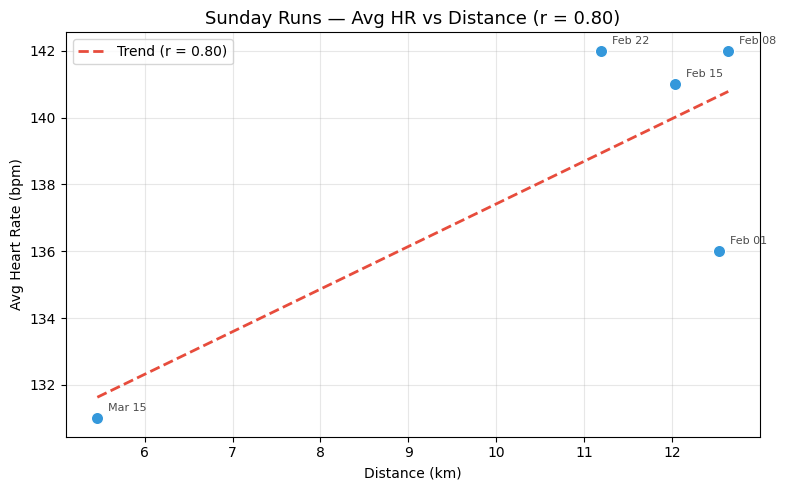

Correlation coefficient: 0.798


,WorkoutDay,Title,DistanceKm,HeartRateAverage
0,2026-02-01,Z2 - לפי דופק,12.52884,136.0
10,2026-02-08,Run z2 80min,12.63752,142.0
22,2026-02-15,Run z2 70min,12.03211,141.0
33,2026-02-22,Run z2 70min,11.19004,142.0
74,2026-03-15,Running,5.46189,131.0


In [90]:


# Filter Sunday runs
df_sunday_runs = df_selected[
    (df_selected['WorkoutType'] == 'Run') & 
    (df_selected['DayOfWeek'] == 'Sunday')
].copy()

df_sunday_runs = df_sunday_runs.dropna(subset=['WorkoutDay']).sort_values('WorkoutDay')
df_sunday_runs['HeartRateAverage'] = pd.to_numeric(df_sunday_runs['HeartRateAverage'], errors='coerce')
df_sunday_runs['DistanceKm'] = pd.to_numeric(df_sunday_runs['DistanceInMeters'], errors='coerce') / 1000

# Drop rows with missing values for correlation
df_corr = df_sunday_runs.dropna(subset=['HeartRateAverage', 'DistanceKm'])

# Calculate correlation
corr = df_corr['HeartRateAverage'].corr(df_corr['DistanceKm'])

# Scatter plot with trend line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_corr['DistanceKm'], df_corr['HeartRateAverage'], s=80, color='#3498db', edgecolors='white', zorder=3)

# Trend line
z = np.polyfit(df_corr['DistanceKm'], df_corr['HeartRateAverage'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_corr['DistanceKm'].min(), df_corr['DistanceKm'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#e74c3c', linewidth=2, label=f'Trend (r = {corr:.2f})')

# Annotate each point with the date
for _, row in df_corr.iterrows():
    ax.annotate(row['WorkoutDay'].strftime('%b %d'),
                (row['DistanceKm'], row['HeartRateAverage']),
                textcoords="offset points", xytext=(8, 5), fontsize=8, alpha=0.7)

ax.set_title(f'Sunday Runs — Avg HR vs Distance (r = {corr:.2f})', fontsize=13)
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Avg Heart Rate (bpm)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Correlation coefficient: {corr:.3f}")
df_corr[['WorkoutDay', 'Title', 'DistanceKm', 'HeartRateAverage']]

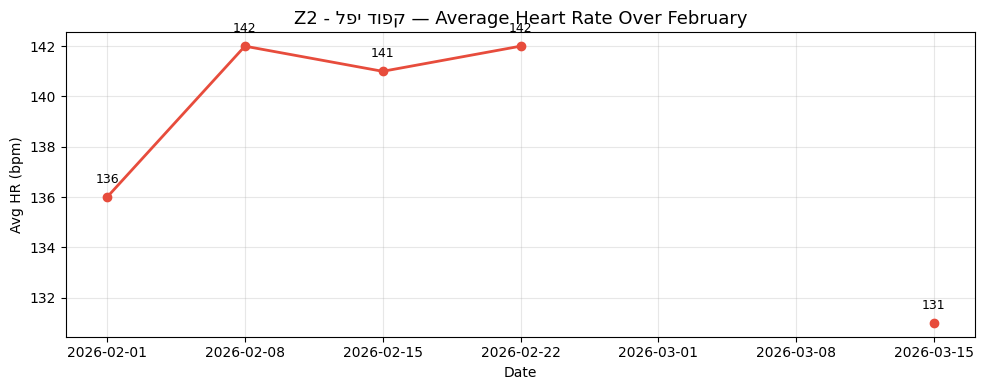


Found 6 Z2 sessions


,WorkoutDay,DayOfWeek,HeartRateAverage,DistanceInMeters,TimeTotalInHours
0,2026-02-01,Sunday,136.0,12528.839844,1.382449
10,2026-02-08,Sunday,142.0,12637.519531,1.333839
22,2026-02-15,Sunday,141.0,12032.110352,1.291362
33,2026-02-22,Sunday,142.0,11190.040039,1.166819
71,2026-03-15,Sunday,NaN,NaN,NaN
74,2026-03-15,Sunday,131.0,5461.890137,0.847392


In [91]:
import matplotlib.pyplot as plt


df_sunday_runs['HeartRateAverage'] = pd.to_numeric(df_sunday_runs['HeartRateAverage'], errors='coerce')

# Line plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sunday_runs['WorkoutDay'], df_sunday_runs['HeartRateAverage'], marker='o', linewidth=2, color='#e74c3c')

# Annotate each point
for _, row in df_sunday_runs.iterrows():
    ax.annotate(f"{row['HeartRateAverage']:.0f}",
                (row['WorkoutDay'], row['HeartRateAverage']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Z2 - לפי דופק — Average Heart Rate Over February', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Avg HR (bpm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFound {len(df_sunday_runs)} Z2 sessions")
df_sunday_runs[['WorkoutDay', 'DayOfWeek', 'HeartRateAverage', 'DistanceInMeters', 'TimeTotalInHours']]

In [94]:
!pip install plotly.graph_objects

ERROR: Could not find a version that satisfies the requirement plotly.graph_objects (from versions: none)
ERROR: No matching distribution found for plotly.graph_objects
